# Humpback Whale Identification — Classification Baseline

**Course**: Machine Learning for Computer Vision (91266)  
**Task**: [Kaggle Whale Identification Playground](https://www.kaggle.com/competitions/whale-categorization-playground)  
**Authors**: Kristoffer Osen & Sebastian Munthe

## Overview

This notebook implements an improved image classification baseline for humpback whale
identification from fluke photographs. The task is extremely challenging:
- ~4000+ whale identities, most with only 1–5 training images
- A large "new_whale" class representing unidentified individuals
- Fine-grained visual differences (trailing-edge notches, pigmentation patterns)

We systematically address the overfitting problem observed in naive approaches through:
1. **Appropriate augmentation** (conservative, preserving identity cues)
2. **Better backbone** (EfficientNet-B5 at 456px for fine-grained detail)
3. **Freeze/unfreeze training** (preserve pretrained features, then fine-tune)
4. **Focal Loss** (handles extreme class imbalance better than cross-entropy)

All hyperparameters are controlled via a single configuration object, experiments
are indexed and checkpointed automatically, and training can resume from any point.


## Setup & Imports

In [5]:
import sys
import os
import torch
import json

# Ensure our project modules are importable
sys.path.insert(0, os.path.dirname(os.path.abspath("__file__")))

from config import ExperimentConfig
from experiment import ExperimentManager
from dataset import prepare_data, build_dataloaders
from models import WhaleClassifier
from losses import build_loss
from training import train
from evaluation import evaluate
from visualization import plot_training_history

# Device setup
if torch.cuda.is_available():
    device = torch.device("cuda")
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")
elif hasattr(torch.backends, "mps") and torch.backends.mps.is_available():
    device = torch.device("mps")
    print("Using Apple MPS")
else:
    device = torch.device("cpu")
    print("WARNING: No GPU detected. Training will be very slow.")

print(f"PyTorch: {torch.__version__}")
print(f"Device: {device}")


GPU: NVIDIA RTX PRO 4000 Blackwell
VRAM: 25.2 GB
PyTorch: 2.10.0+cu130
Device: cuda


## Experiment Configuration


In [6]:
config = ExperimentConfig(
    experiment_name="baseline_effnetb5_cross_entropy",
    description="EfficientNet-B5 with plain Cross Entropy, no class weights, no smoothing",
    data_dir="data",
    experiments_root="experiments",

    loss_type="ce",
    use_class_weights=False,
    label_smoothing=0.0,

    epochs=25,
    early_stopping_patience=3,
    early_stopping_metric="val_known_acc",

    freeze_backbone_epochs=3,

    scheduler="cosine",
    warmup_epochs=1,
)

print("Experiment config:")
print(config.summary())


Experiment config:
efficientnet_b5 | 456px | ce(γ=2.0) | lr=0.0001/0.001 | freeze=3ep | bs=12×2


## Data Preparation

In [ ]:
data = prepare_data(config)

print(f"\nClass mapping: {data['num_classes']} known whale identities")
print(f"ID → Index examples: {dict(list(data['id_to_idx'].items())[:5])} ...")

[split] Stratified test split infeasible on frequent classes; using shuffled split.
[split] Stratified val split infeasible on frequent classes; using shuffled split.
Dataset split:
  Train:    8089 images, 4247 known classes (filtered 647 new_whale)
  Val:       557 images (88 are new_whale)
  Test:      557 images (75 are new_whale)
  Class distribution: min=1 median=1 max=24 samples/class

Class mapping: 4247 known whale identities
ID → Index examples: {'w_0013924': 0, 'w_001ebbc': 1, 'w_002222a': 2, 'w_002b682': 3, 'w_002dc11': 4} ...


## Train

The training procedure has two phases:

**Phase 1 — Frozen backbone** (epochs 0–2):
Only the embedding layer and classifier head are trained. This lets the new
head learn sensible weights using stable pretrained features, preventing the
backbone from being corrupted by random gradients from the untrained head.

**Phase 2 — Full fine-tuning** (epochs 3+):
The backbone is unfrozen with a 10× lower learning rate than the head.
BatchNorm layers remain in eval mode throughout (their ImageNet statistics
are more reliable than statistics from our micro-batches).

Training uses:
- **AMP** (Automatic Mixed Precision) for ~50% memory reduction
- **Gradient accumulation** (4 steps) for effective batch size of 32
- **Cosine annealing** with linear warmup
- **Gradient clipping** at norm 1.0


In [4]:
TRAINING_ENABLED = True
EXPERIMENT_ID = "20260524_230915_baseline_effnetb5_cross_entrop_a55bddfe" 

if TRAINING_ENABLED:
    # To resume a previous run, set resume_from to its experiment ID:
    manager = train(config, data, device, resume_from=EXPERIMENT_ID)
    # To start fresh:
    #manager = train(config, data, device)
else:
    print("Skipping training")
    config = ExperimentConfig.load("experiments/" + EXPERIMENT_ID + "/config.json")
    manager = ExperimentManager(config, EXPERIMENT_ID)
    

[00:11:36] Resumed experiment: 20260524_230915_baseline_effnetb5_cross_entrop_a55bddfe
[00:11:36] Config: efficientnet_b5 | 456px | ce(γ=2.0) | lr=0.0001/0.001 | freeze=3ep | bs=12×2
[00:11:36] Resume mode active for experiment: 20260524_230915_baseline_effnetb5_cross_entrop_a55bddfe


[00:11:38] Resume checkpoint indicates UNFROZEN optimizer state.

Model: efficientnet_b5 (head=linear)
  Input size:     (456, 456)
  Embedding dim:  512
  Total params:     31,569,607
  Backbone:         28,340,784
  Head:              3,228,823
  Trainable:        31,569,607 (100.0%)
  Frozen:                    0 (0.0%)

[00:11:38] Loss: ce | Head: linear
[00:11:38] Loading checkpoint: experiments/20260524_230915_baseline_effnetb5_cross_entrop_a55bddfe/checkpoints/latest.pth
[00:11:39] Resuming from epoch 25
[00:11:39] 
Starting training: 30 epochs, effective batch size = 24


  Train Ep 25:   0%|          | 0/674 [00:00<?, ?it/s]

  Val   Ep 25:   0%|          | 0/24 [00:00<?, ?it/s]

[00:15:00] Epoch  25/30 [UNFROZEN] | Train Loss: 0.0042  Acc: 99.9% | Val val_known_acc: 38.5%  LR: 6.67e-06 | Time: 3.4m


...

  Val   Ep 28:   0%|          | 0/24 [00:00<?, ?it/s]

[00:21:47] Epoch  28/30 [UNFROZEN] | Train Loss: 0.0018  Acc: 99.9% | Val val_known_acc: 40.0%  LR: 1.36e-06 | Time: 2.2m
[00:21:58]   ✓ New best model saved (epoch 28, val_known_acc=0.4004)


  Train Ep 29:   0%|          | 0/674 [00:00<?, ?it/s]

  Val   Ep 29:   0%|          | 0/24 [00:00<?, ?it/s]

[00:24:37] Epoch  29/30 [UNFROZEN] | Train Loss: 0.0019  Acc: 99.9% | Val val_known_acc: 39.6%  LR: 1.00e-06 | Time: 2.7m
[00:24:48] 
Training complete in 13.2 minutes.
[00:24:48] Best epoch: 28 (val_known_acc=0.4004)


## Training Analysis

/root/ML4CV/visualization.py:75: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(loc="upper left")


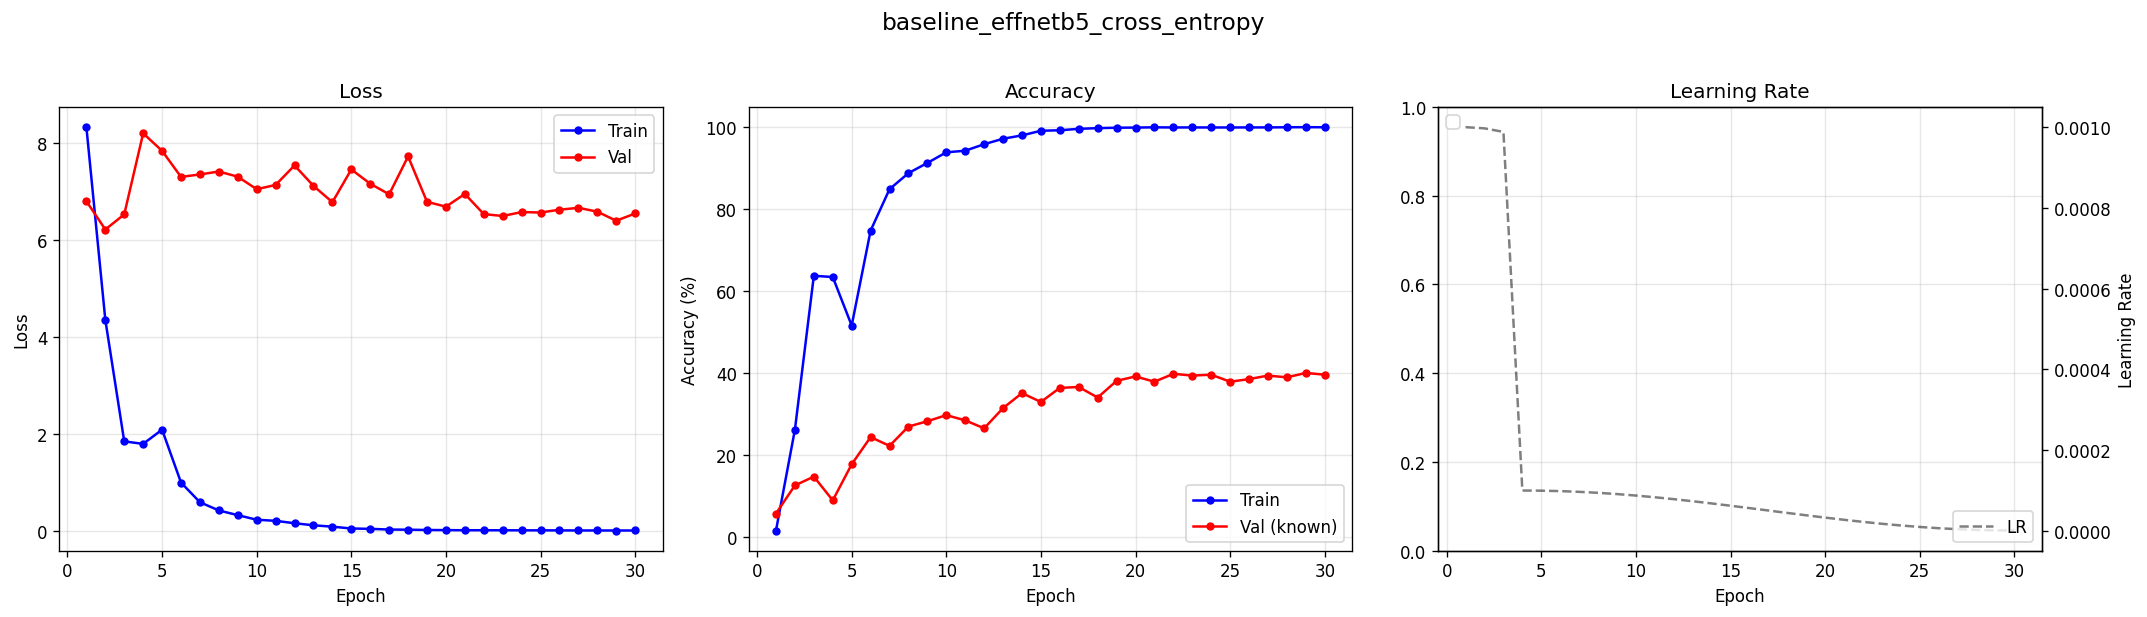

In [7]:
# Load metrics from the completed experiment
metrics_path = manager.root / "metrics.json"
with open(metrics_path, "r") as f:
    metrics = json.load(f)

plot_training_history(metrics, title=config.experiment_name)


In [8]:
print("\nFinal metrics (last epoch):")
for key in ["train_loss", "val_loss", "val_known_acc",
            "val_mean_known_conf"]:
    if key in metrics:
        val = metrics[key][-1]
        if "acc" in key or "detection" in key:
            print(f"  {key:<30s}: {val * 100:.2f}%")
        else:
            print(f"  {key:<30s}: {val:.4f}")



Final metrics (last epoch):
  train_loss                    : 0.0019
  val_loss                      : 6.5491
  val_known_acc                 : 39.61%
  val_mean_known_conf           : 0.7421


## Evaluate Best Model


In [9]:
# Load best model

best_model = WhaleClassifier(
    backbone_name=config.backbone,
    num_classes=data["num_classes"],
    embedding_dim=config.embedding_dim,
    pretrained=False,  # Loading trained weights instead
).to(device)

manager.load_checkpoint(best_model, checkpoint="best")

# Run evaluation
criterion = build_loss(config, data["class_counts"], device)
val_metrics = evaluate(best_model, val_loader, criterion, config, device, epoch=0)

print("\nBest model validation metrics:")
for k, v in val_metrics.items():
    if isinstance(v, float):
        if "acc" in k or "detection" in k:
            print(f"  {k:<30s}: {v * 100:.2f}%")
        else:
            print(f"  {k:<30s}: {v:.4f}")
    else:
        print(f"  {k:<30s}: {v}")


[00:29:58] Loading checkpoint: experiments/20260524_230915_baseline_effnetb5_cross_entrop_a55bddfe/checkpoints/best.pth
[00:29:58] Resuming from epoch 29


  Val   Ep 0:   0%|          | 0/24 [00:00<?, ?it/s]


Best model validation metrics:
  val_loss                      : 6.3992
  val_known_acc                 : 40.04%
  val_known_top5_acc            : 55.03%
  val_mean_known_conf           : 0.7423
  val_mean_new_whale_conf       : 0.6792
  val_known_total               : 467
  val_new_whale_total           : 90


## Embedding Quality

In [15]:
# ── Load the best baseline model ──────────────────────────────────
from pathlib import Path

from dataset import build_retrieval_eval_loaders
from dataset import get_eval_config_and_data
from evaluation import evaluate_retrieval
from models import build_model

eval_config, data = get_eval_config_and_data()

BASELINE_CHECKPOINT = "experiments/20260524_230915_baseline_effnetb5_cross_entrop_a55bddfe/checkpoints/best.pth"

try:
    ckpt_path = Path(BASELINE_CHECKPOINT)
    baseline_config_path = ckpt_path.parent.parent / "config.json"
    baseline_train_config = ExperimentConfig.load(str(baseline_config_path))

    baseline_model = build_model(
        baseline_train_config,
        num_classes=data["num_classes"],
        device=device,
    )

    state = torch.load(BASELINE_CHECKPOINT, map_location=device, weights_only=False)
    baseline_model.load_state_dict(state["model_state_dict"])

    print("Baseline model loaded successfully.")
    print(f"Using baseline training config: {baseline_config_path}")

    # Retrieval evaluation with shared protocol (comparable across models)
    train_loader, val_loader = build_retrieval_eval_loaders(eval_config, data)

    print("\nBaseline retrieval performance:")
    baseline_retrieval = evaluate_retrieval(
        baseline_model, train_loader, val_loader,
        eval_config, device,
    )
except FileNotFoundError:
    print(f"Baseline checkpoint not found at: {BASELINE_CHECKPOINT}")
    print("Train the baseline first using notebook 01, then update the path above.")
    baseline_model = None

[split] Stratified test split infeasible on frequent classes; using shuffled split.
[split] Stratified val split infeasible on frequent classes; using shuffled split.
Dataset split:
  Train:    8089 images, 4247 known classes (filtered 647 new_whale)
  Val:       557 images (88 are new_whale)
  Test:      557 images (75 are new_whale)
  Class distribution: min=1 median=1 max=24 samples/class
Baseline model loaded successfully.
Using baseline training config: experiments/20260524_230915_baseline_effnetb5_cross_entrop_a55bddfe/config.json

Baseline retrieval performance:


  Extracting embeddings:   0%|          | 0/338 [00:00<?, ?it/s]

  Gallery: 8089 embeddings, 4247 identities


  Extracting embeddings:   0%|          | 0/24 [00:00<?, ?it/s]

  Recall@1: 60.17%  Recall@5: 71.73%  


### t-SNE Visualization


  Extracting embeddings:   0%|          | 0/24 [00:00<?, ?it/s]

  Extracting embeddings:   0%|          | 0/674 [00:00<?, ?it/s]

t-SNE: 221 points, 10 classes (min 5/class)


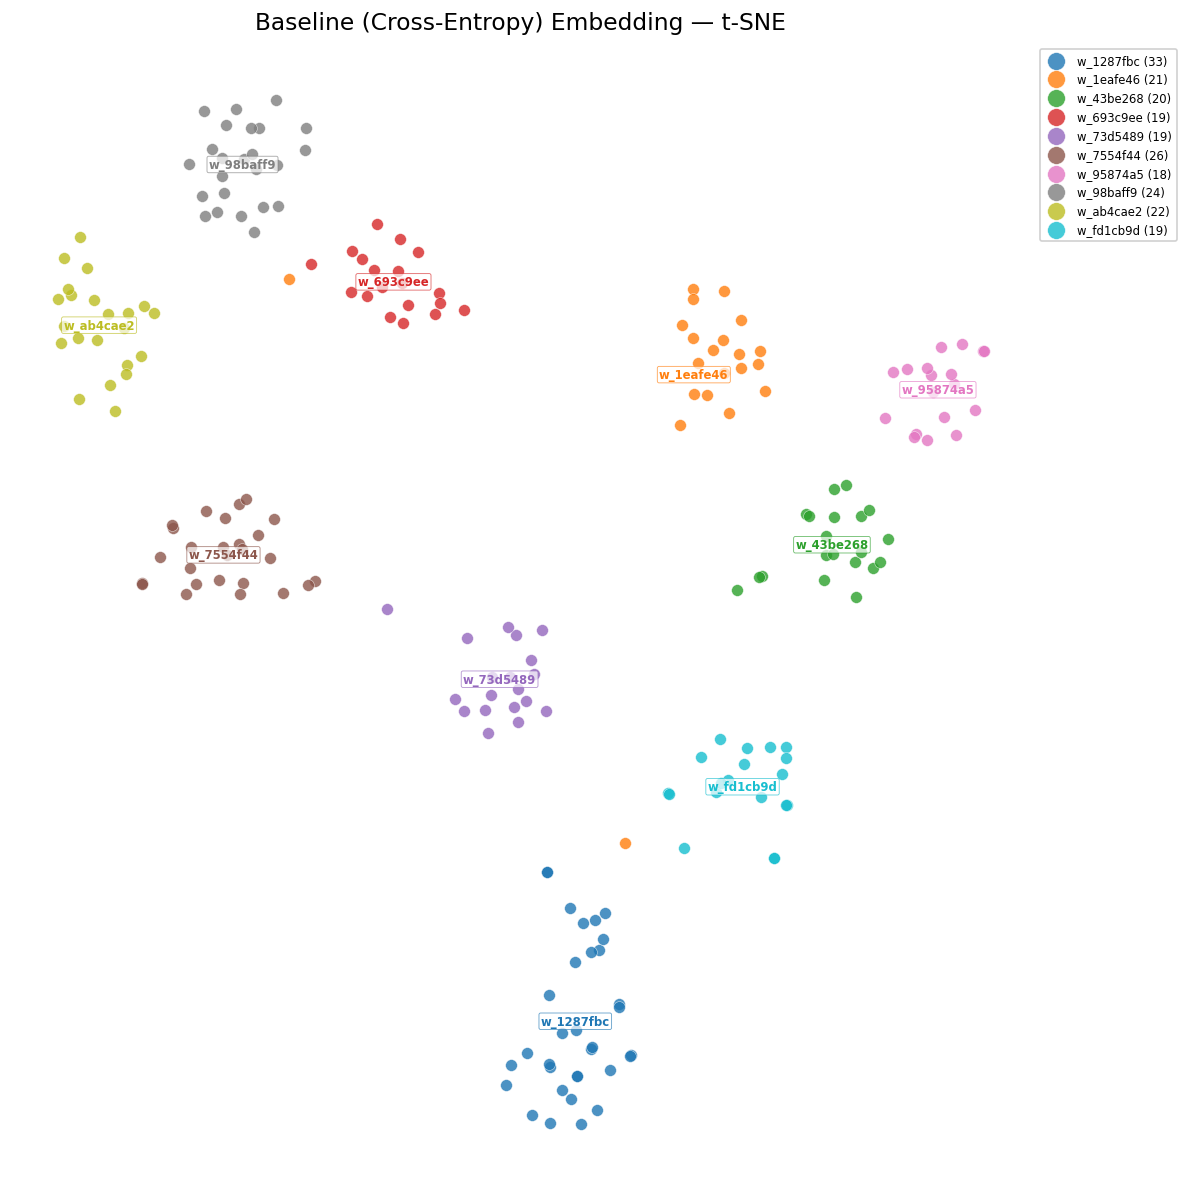

  Perplexity used: 27 | KL divergence: 0.25


In [16]:
# ── Usage ────────────────────────────────────────────────────────────────
# Combine train + val loaders to get enough points per class for visible clusters.
# This is purely for visualization — evaluation metrics stay on val only.
from visualization import plot_embedding_tsne

if baseline_model is not None:
    train_loader_viz, val_loader_viz = build_dataloaders(eval_config, data)
    plot_embedding_tsne(
        baseline_model, val_loader_viz, data, device,
        title="Baseline (Cross-Entropy) Embedding — t-SNE",
        top_k_classes=10,
        min_samples_per_class=5,
        combine_loaders=[train_loader_viz],
    )